In [1]:
# Open training, testing subsets from https://doi.org/10.1021/acs.energyfuels.0c01533
from csv import DictReader

with open('schweidtmann_train.csv', 'r') as csv_file:
    reader = DictReader(csv_file)
    compounds_train = [r for r in reader]
csv_file.close()
with open('schweidtmann_test.csv', 'r') as csv_file:
    reader = DictReader(csv_file)
    compounds_test = [r for r in reader]
csv_file.close()

print(len(compounds_train), len(compounds_test))

# Filter out compounds with `n.a.` RON or MON data
compounds_train = [c for c in compounds_train if c['Meas RON'] != 'n.a.' and c['Meas MON'] != 'n.a.']
compounds_test = [c for c in compounds_test if c['Meas RON'] != 'n.a.' and c['Meas MON'] != 'n.a.']

print(len(compounds_train), len(compounds_test))

430 75
265 51


In [2]:
# Format data for training
from ecnet.datasets.structs import QSPRDataset

smiles_train = [c[' SMILES'] for c in compounds_train]
ron_train = [[float(c['Meas RON'])] for c in compounds_train]
mon_train = [[float(c['Meas MON'])] for c in compounds_train]

smiles_test = [c[' SMILES'] for c in compounds_test]
ron_test = [[float(c['Meas RON'])] for c in compounds_test]
mon_test = [[float(c['Meas MON'])] for c in compounds_test]

dataset_train_ron = QSPRDataset(smiles_train, ron_train, backend='alvadesc')
dataset_train_mon = QSPRDataset(smiles_train, mon_train, backend='alvadesc')
dataset_test_ron = QSPRDataset(smiles_test, ron_test, backend='alvadesc')
dataset_test_mon = QSPRDataset(smiles_test, mon_test, backend='alvadesc')

In [3]:
# Select most-influential descriptors w.r.t. RON and MON for NN input variables
from ecnet.tasks.feature_selection import select_rfr

# Retain descriptors such that 99.9% of descriptor-property correlation is retained
desc_idx_ron, desc_imp_ron = select_rfr(dataset_train_ron, total_importance=0.999, n_estimators=64, n_jobs=8)
desc_idx_mon, desc_imp_mon = select_rfr(dataset_train_mon, total_importance=0.999, n_estimators=64, n_jobs=8)

dataset_train_ron.set_desc_index(desc_idx_ron)
dataset_train_mon.set_desc_index(desc_idx_mon)
dataset_test_ron.set_desc_index(desc_idx_ron)
dataset_test_mon.set_desc_index(desc_idx_mon)
print(dataset_train_mon.desc_vals.shape, dataset_test_mon.desc_vals.shape)
print(dataset_train_ron.desc_vals.shape, dataset_test_ron.desc_vals.shape)
print(dataset_train_mon.desc_names[:5], desc_imp_mon[:5])
print(dataset_train_ron.desc_names[:5], desc_imp_ron[:5])

torch.Size([265, 1073]) torch.Size([51, 1073])
torch.Size([265, 1028]) torch.Size([51, 1028])
['GATS2m', 'SssCH2', 'Eta_L_A', 'X5Av', 'CIC1'] [0.38346699994994304, 0.048833944019229414, 0.015117179716474319, 0.01459808134154118, 0.014438778452306565]
['ChiA_B(s)', 'SssCH2', 'GATS2m', 'SpMaxA_EA(bo)', 'Eta_L_A'] [0.2503009466149289, 0.19606088559811766, 0.11330111614280106, 0.01813243500927824, 0.01713078051638765]


In [4]:
# Create ECNet model
from ecnet import ECNet
from math import sqrt
from matplotlib import pyplot as plt

models_ron = []
models_mon = []

for i in range(10):

    print(f'Model {i}')
    model_ron = ECNet(dataset_train_ron.desc_vals.shape[1], dataset_train_ron.target_vals.shape[1], 1024, 1, 0.0)
    train_loss, valid_loss = model_ron.fit(
        dataset=dataset_train_ron, valid_size=0.25, shuffle=True, verbose=25,
        patience=64, epochs=1024, lr=0.0005, lr_decay=0.0, batch_size=8
    )
    models_ron.append(model_ron)

    model_mon = ECNet(dataset_train_mon.desc_vals.shape[1], dataset_train_mon.target_vals.shape[1], 1024, 1, 0.0)
    train_loss, valid_loss = model_mon.fit(
        dataset=dataset_train_mon, valid_size=0.25, shuffle=True, verbose=25,
        patience=64, epochs=1024, lr=0.0005, lr_decay=0.0, batch_size=8
    )
    models_mon.append(model_mon)

Model 0
Epoch: 0 | Train loss: 1846.1722257980193 | Valid loss: 9223372036854775807
Epoch: 25 | Train loss: 136.2967011037499 | Valid loss: 225.29591369628906
Epoch: 50 | Train loss: 65.68712918445317 | Valid loss: 76.06394958496094
Epoch: 75 | Train loss: 64.41180092397363 | Valid loss: 110.05037689208984
Epoch: 100 | Train loss: 49.516110352795536 | Valid loss: 41.35992431640625
Epoch: 125 | Train loss: 48.20510898936879 | Valid loss: 35.62051010131836
Epoch: 150 | Train loss: 47.044776068793404 | Valid loss: 40.42623519897461
Epoch: 175 | Train loss: 29.98455146828083 | Valid loss: 34.96027755737305
Epoch: 200 | Train loss: 44.538363003971604 | Valid loss: 43.7053108215332
Epoch: 225 | Train loss: 40.9460717210866 | Valid loss: 40.49695587158203
Epoch: 250 | Train loss: 48.631023320284754 | Valid loss: 73.41873168945312
Epoch: 275 | Train loss: 37.78007688426008 | Valid loss: 51.50547409057617
Epoch: 300 | Train loss: 24.227073226312193 | Valid loss: 15.17672348022461
Epoch: 325 | T

In [5]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

y_hat_trains_ron = []
for i in range(len(models_ron)):
    y_hat_trains_ron.append(models_ron[i](dataset_train_ron.desc_vals).detach().numpy())
y_hat_trains_ron = np.asarray(y_hat_trains_ron)
y_hat_train_ron = np.mean(y_hat_trains_ron, axis=0)
y_train_ron = dataset_train_ron.target_vals.detach().numpy()

y_hat_tests_ron = []
for i in range(len(models_ron)):
    y_hat_tests_ron.append(models_ron[i](dataset_test_ron.desc_vals).detach().numpy())
y_hat_tests_ron = np.asarray(y_hat_tests_ron)
y_hat_test_ron = np.mean(y_hat_tests_ron, axis=0)
y_test_ron = dataset_test_ron.target_vals.detach().numpy()

y_hat_trains_mon = []
for i in range(len(models_mon)):
    y_hat_trains_mon.append(models_mon[i](dataset_train_mon.desc_vals).detach().numpy())
y_hat_trains_mon = np.asarray(y_hat_trains_mon)
y_hat_train_mon = np.mean(y_hat_trains_mon, axis=0)
y_train_mon = dataset_train_mon.target_vals.detach().numpy()

y_hat_tests_mon = []
for i in range(len(models_mon)):
    y_hat_tests_mon.append(models_mon[i](dataset_test_mon.desc_vals).detach().numpy())
y_hat_tests_mon = np.asarray(y_hat_tests_mon)
y_hat_test_mon = np.mean(y_hat_tests_mon, axis=0)
y_test_mon = dataset_test_mon.target_vals.detach().numpy()

mae_ron_train = mean_absolute_error(y_hat_train_ron, y_train_ron)
mae_ron_test = mean_absolute_error(y_hat_test_ron, y_test_ron)
mae_mon_train = mean_absolute_error(y_hat_train_mon, y_train_mon)
mae_mon_test = mean_absolute_error(y_hat_test_mon, y_test_mon)
r2_ron_train = r2_score(y_hat_train_ron, y_train_ron)
r2_ron_test = r2_score(y_hat_test_ron, y_test_ron)
r2_mon_train = r2_score(y_hat_train_mon, y_train_mon)
r2_mon_test = r2_score(y_hat_test_mon, y_test_mon)

print(f'RON Train: {mae_ron_train} | {r2_ron_train}')
print(f'RON Test: {mae_ron_test} | {r2_ron_test}')
print(f'MON Train: {mae_mon_train} | {r2_mon_train}')
print(f'MON Test: {mae_mon_test} | {r2_mon_test}')

RON Train: 1.6743494272232056 | 0.991750793382713
RON Test: 4.982872009277344 | 0.9218658793111271
MON Train: 1.3180454969406128 | 0.9923689297471432
MON Test: 4.352466106414795 | 0.9017742986869735


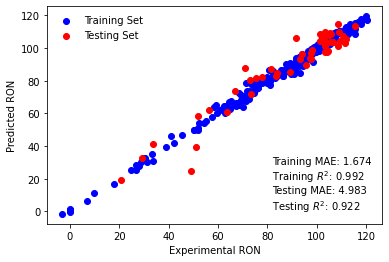

In [6]:
from matplotlib.offsetbox import AnchoredText

plt.clf()
plt.xlabel('Experimental RON')
plt.ylabel('Predicted RON')
plt.scatter(y_train_ron, y_hat_train_ron, color='blue', label='Training Set')
plt.scatter(y_test_ron, y_hat_test_ron, color='red', label='Testing Set')
plt.legend(loc='upper left', edgecolor='w')
string = 'Training MAE: {:.3f}'.format(mae_ron_train) + '\n'
string += 'Training $R^2$: {:.3f}'.format(r2_ron_train) + '\n'
string += 'Testing MAE: {:.3f}'.format(mae_ron_test) + '\n'
string += 'Testing $R^2$: {:.3f}'.format(r2_ron_test)
text_box = AnchoredText(string, frameon=True, loc=4, pad=0.5)
plt.setp(text_box.patch, facecolor='white', edgecolor='w')
plt.gca().add_artist(text_box)
plt.show()

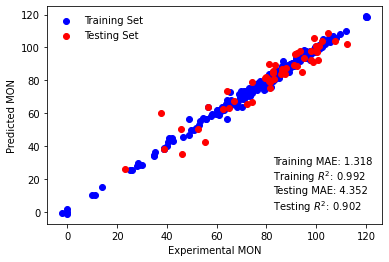

In [7]:
plt.clf()
plt.xlabel('Experimental MON')
plt.ylabel('Predicted MON')
plt.scatter(y_train_mon, y_hat_train_mon, color='blue', label='Training Set')
plt.scatter(y_test_mon, y_hat_test_mon, color='red', label='Testing Set')
plt.legend(loc='upper left', edgecolor='w')
string = 'Training MAE: {:.3f}'.format(mae_mon_train) + '\n'
string += 'Training $R^2$: {:.3f}'.format(r2_mon_train) + '\n'
string += 'Testing MAE: {:.3f}'.format(mae_mon_test) + '\n'
string += 'Testing $R^2$: {:.3f}'.format(r2_mon_test)
text_box = AnchoredText(string, frameon=True, loc=4, pad=0.5)
plt.setp(text_box.patch, facecolor='white', edgecolor='w')
plt.gca().add_artist(text_box)
plt.show()